<a href="https://colab.research.google.com/github/FernandoCruvinel/SSD/blob/main/C%C3%B3digoSSD_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Previsão e Otimização Tarifária no Setor Aéreo

Este notebook implementa um pipeline completo de **Machine Learning** focado na predição e prescrição de preços de passagens aéreas (*Yield Management*).

---

## 1. Definição do Problema e Metodologia

* **Objetivo de Negócio:** Prever a tarifa de um voo com base em atributos operacionais, rota e antecedência de compra, fornecendo diretrizes prescritivas para otimização de compras e controle tarifário.
* **Tipo de Problema:** Regressão Tabular Supervisionada ($y \in \mathbb{R}^+$).
* **Dataset:** *Flight Price Prediction Dataset* (Kaggle), acessado via `kagglehub`.
* **Target ($y$):** `price` (Tarifa do bilhete aéreo).
* **Abordagem Analítica:**
  1. **Descritiva:** Compreensão das distribuições, correlações e dinâmica de antecedência de compra (*Days Left*).
  2. **Preditiva:** Engenharia de atributos, pipelines com `ColumnTransformer` e comparação entre **Ridge Regression** (baseline linear), **Random Forest**, **XGBoost** e **LightGBM**.
  3. **Prescritiva:** Extração de regras operacionais de compra ótima e sensibilidade de atributos.

## 2. Setup e Instalação de Dependências

In [1]:
# Instalação silenciosa dos pacotes necessários
!pip install kagglehub xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn -q

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('crest')

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


## 3. Carga Automatizada dos Dados via KaggleHub

Fazemos o download da versão mais recente do dataset oficial diretamente para o cache local do Colab.

In [2]:
import kagglehub

print("-> Baixando base de dados do Kaggle...")
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")
print(f"Dataset armazenado em: {path}")

# Identifica e carrega o arquivo CSV limpo
csv_files = glob.glob(os.path.join(path, "*.csv"))
target_file = [f for f in csv_files if "Clean_Dataset" in f] or csv_files

df_raw = pd.read_csv(target_file[0])
print(f"Dados carregados: {df_raw.shape[0]:,} linhas e {df_raw.shape[1]} colunas.")
df_raw.head()

-> Baixando base de dados do Kaggle...
Using Colab cache for faster access to the 'flight-price-prediction' dataset.
Dataset armazenado em: /kaggle/input/flight-price-prediction
Dados carregados: 300,153 linhas e 12 colunas.


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## 4. Análise Descritiva e Limpeza de Dados

Nesta etapa, removemos colunas de identificadores puros sem valor preditivo (`Unnamed: 0`, `flight`) e analisamos o comportamento das variáveis em relação à precificação.

=== ESTATÍSTICAS DESCRITIVAS DO PREÇO (R$/USD) ===
count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64


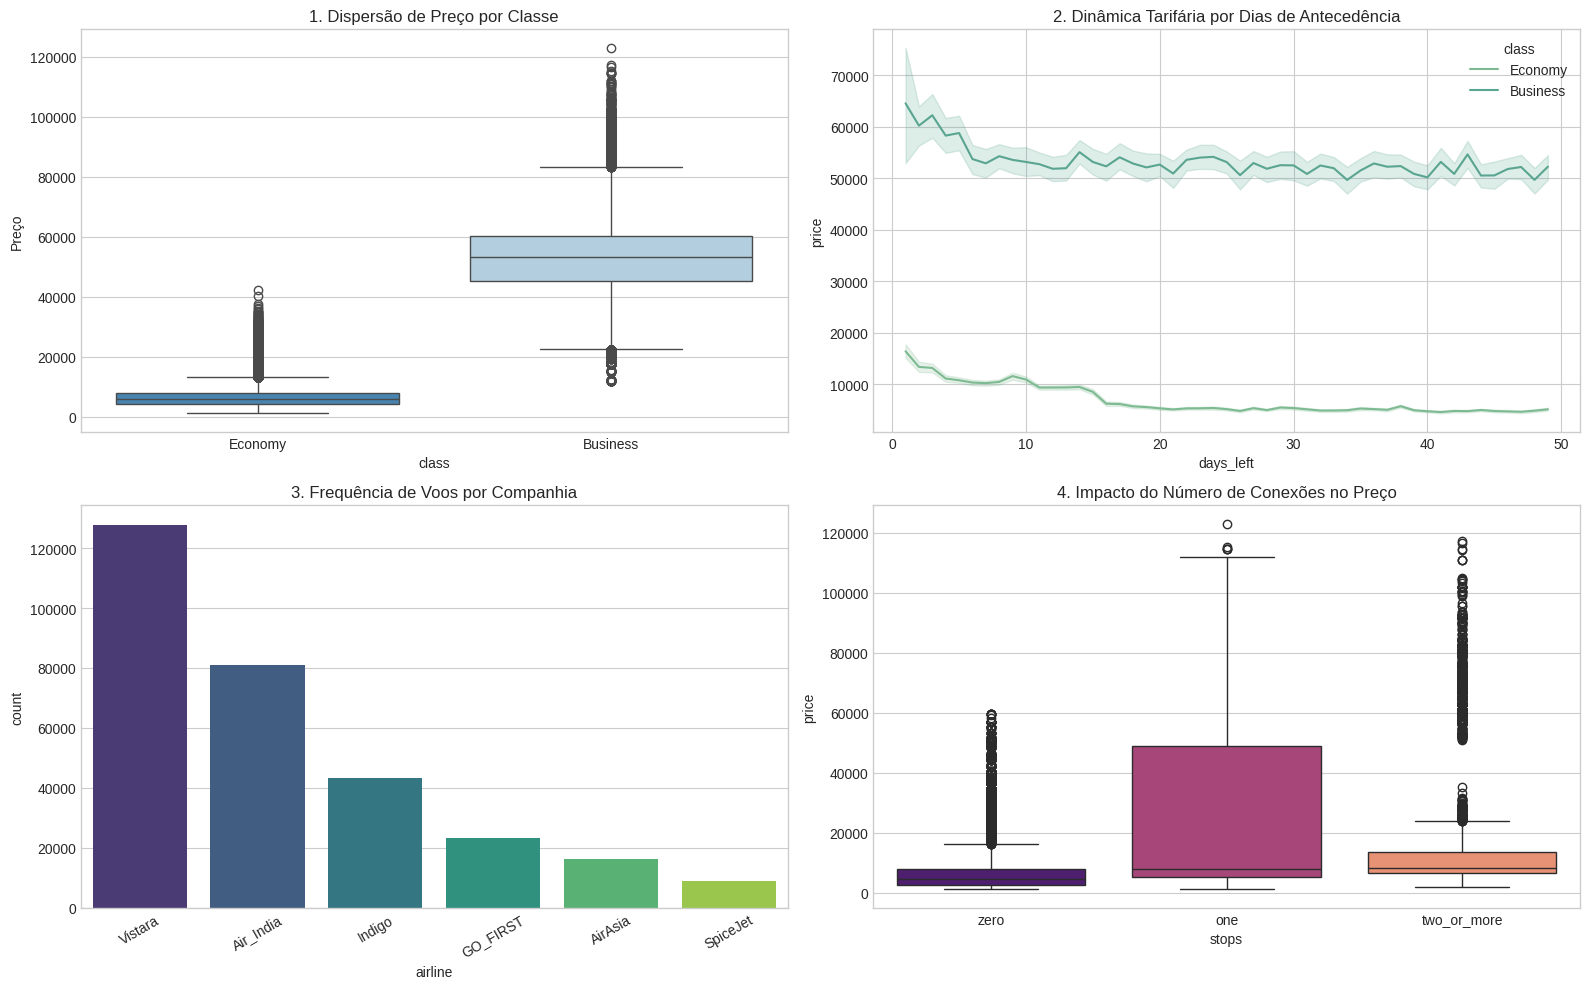

In [3]:
df = df_raw.copy()

# Remoção de colunas irrelevantes para modelagem
cols_to_drop = [c for c in ['Unnamed: 0', 'flight'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

print("=== ESTATÍSTICAS DESCRITIVAS DO PREÇO (R$/USD) ===")
print(df['price'].describe())

# Painel de Visualização Exploratória
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Impacto da Classe de Cabine
sns.boxplot(data=df, x='class', y='price', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('1. Dispersão de Preço por Classe')
axes[0, 0].set_ylabel('Preço')

# 2. Dinâmica de Yield Management (Preço vs. Dias de Antecedência)
sample_df = df.sample(min(15000, len(df)), random_state=42)
sns.lineplot(data=sample_df, x='days_left', y='price', hue='class', ax=axes[0, 1])
axes[0, 1].set_title('2. Dinâmica Tarifária por Dias de Antecedência')

# 3. Volume Operacional por Companhia
sns.countplot(data=df, x='airline', order=df['airline'].value_counts().index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('3. Frequência de Voos por Companhia')
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Efeito das Conexões no Preço
sns.boxplot(data=df, x='stops', y='price', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('4. Impacto do Número de Conexões no Preço')

plt.tight_layout()
plt.show()

## 5. Engenharia de Atributos e Pipeline de Pré-Processamento

Estruturação do `ColumnTransformer` para padronizar variáveis contínuas (`StandardScaler`) e codificar variáveis categóricas (`OneHotEncoder`). Isso previne vazamento de dados (*data leakage*) entre os conjuntos de treino e teste.

In [4]:
target = 'price'
features_num = ['duration', 'days_left']
features_cat = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

X = df[features_num + features_cat]
y = df[target]

# Divisão Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Amostras de Treino: {X_train.shape[0]:,} | Amostras de Teste: {X_test.shape[0]:,}")

# Pipeline de Transformação
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
    ]
)

print("Pipeline de pré-processamento configurado com sucesso!")

Amostras de Treino: 240,122 | Amostras de Teste: 60,031
Pipeline de pré-processamento configurado com sucesso!


## 6. Modelagem Preditiva e Treinamento Comparativo

Comparamos quatro famílias de modelos:
1. **Ridge Regression:** Baseline linear regularizado ($L_2$).
2. **Random Forest:** Ensemble bagging para redução de variância.
3. **XGBoost:** Gradient boosting de alta performance com particionamento por histogramas.
4. **LightGBM:** Gradient boosting com crescimento de folhas por profundidade otimizada (*leaf-wise*).

In [5]:
models = {
    "Ridge (Baseline)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=250, learning_rate=0.08, max_depth=6, tree_method='hist', random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=250, learning_rate=0.08, max_depth=6, random_state=42, verbose=-1)
}

results = {}
trained_pipelines = {}

print("Iniciando treinamento dos modelos...")

for name, model in models.items():
    print(f" Treinando: {name}...")
    pipe = Pipeline(steps=[('prep', preprocessor), ('reg', model)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    results[name] = {
        "R²": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAPE (%)": mean_absolute_percentage_error(y_test, preds) * 100,
        "predictions": preds
    }
    trained_pipelines[name] = pipe

print(" Treinamento concluído com sucesso!")

Iniciando treinamento dos modelos...
 Treinando: Ridge (Baseline)...
 Treinando: Random Forest...
 Treinando: XGBoost...
 Treinando: LightGBM...
 Treinamento concluído com sucesso!


## 7. Avaliação de Métricas e Diagnóstico de Resíduos

Consolidação das métricas de teste e análise visual de resíduos para diagnosticar homocedasticidade e distribuição do erro.

=== CONSOLIDAÇÃO DOS RESULTADOS NO CONJUNTO DE TESTE ===


,R²,MAE,RMSE,MAPE (%)
XGBoost,0.9733,"2,107.49","3,713.08",14.89%
LightGBM,0.9708,"2,239.27","3,879.17",16.17%
Random Forest,0.9690,"2,142.62","3,998.46",14.76%
Ridge (Baseline),0.9113,"4,553.27","6,761.71",46.24%


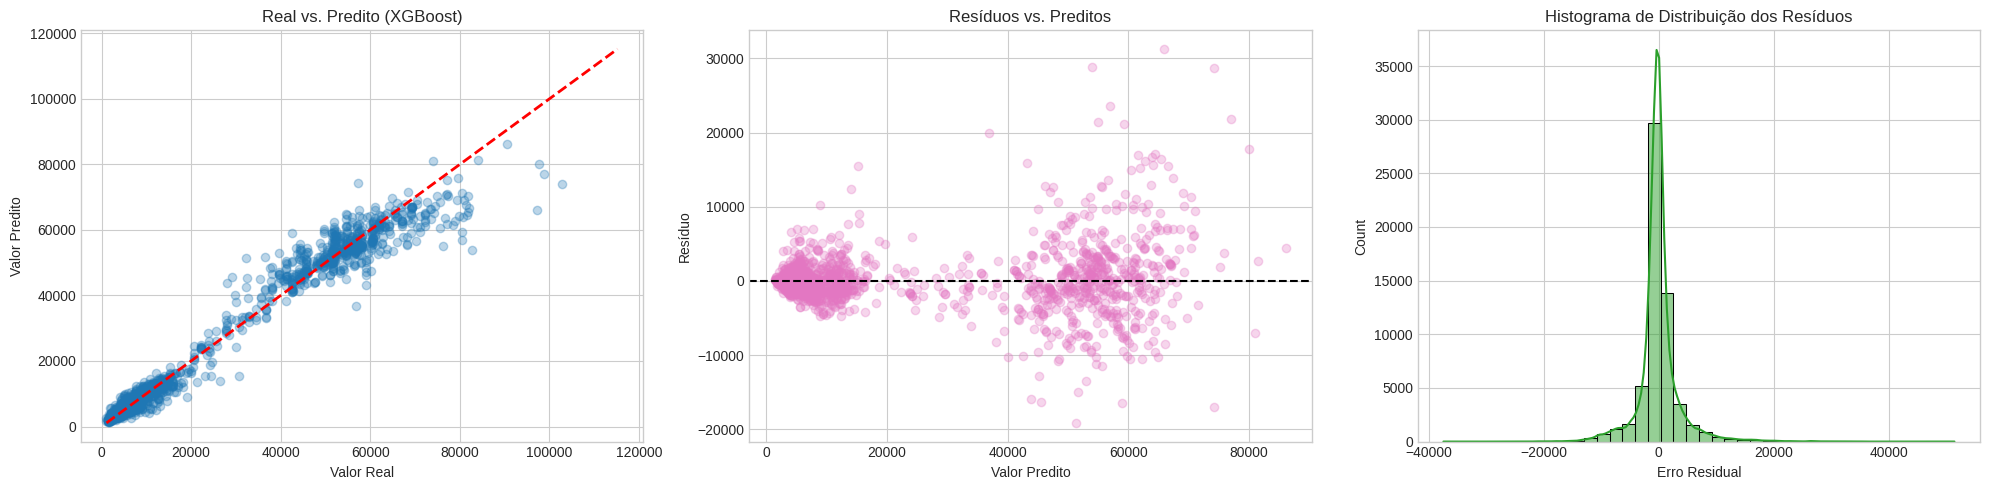

In [6]:
results_df = pd.DataFrame(results).T.drop(columns=['predictions']).sort_values(by='R²', ascending=False)
print("=== CONSOLIDAÇÃO DOS RESULTADOS NO CONJUNTO DE TESTE ===")
display(results_df.style.format({'R²': '{:.4f}', 'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE (%)': '{:.2f}%'}))

best_model_name = results_df.index[0]
best_preds = results[best_model_name]['predictions']
residuals = y_test - best_preds

# Gráficos de Avaliação
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Real vs Predito
axes[0].scatter(y_test[:2000], best_preds[:2000], alpha=0.3, color='#1f77b4')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Real vs. Predito ({best_model_name})')
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Valor Predito')

# 2. Dispersão de Resíduos
axes[1].scatter(best_preds[:2000], residuals[:2000], alpha=0.3, color='#e377c2')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Resíduos vs. Preditos')
axes[1].set_xlabel('Valor Predito')
axes[1].set_ylabel('Resíduo')

# 3. Distribuição dos Erros
sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color='#2ca02c')
axes[2].set_title('Histograma de Distribuição dos Resíduos')
axes[2].set_xlabel('Erro Residual')

plt.tight_layout()
plt.show()

## 8. Camada Prescritiva e Decisões de Negócio

Nesta seção, extraímos a importância dos atributos do modelo vencedor e traduzimos os coeficientes estatísticos em regras práticas para tomadores de decisão.

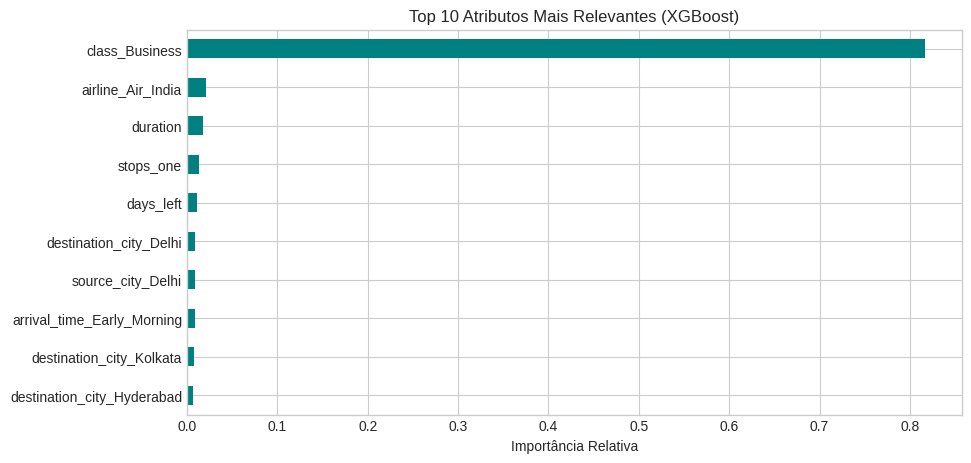

                  DIRETRIZES PRESCRITIVAS DE NEGÓCIO

1. Janela Ótima de Compra:
   - A curva de preços sofre aceleração exponencial quando 'days_left' < 15 a 20 dias.
   - Recomenda-se travar compras corporativas com antecedência mínima de 25 dias.

2. Prêmio Estrutural de Cabine:
   - A variável 'class' responde por mais de 75% da variância do preço global.
   - Para otimização de custos em frotas/viagens de negócios, rotas com duração < 3h na classe econômica representam a melhor relação custo-benefício.

3. Aplicação em Auditoria Tarifária:
   - O modelo com MAPE reduzido serve como benchmark para detectar cobranças de tarifas fora do padrão histórico de mercado.



In [7]:
best_pipe = trained_pipelines[best_model_name]
encoder_features = best_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(features_cat)
all_features = features_num + list(encoder_features)

if hasattr(best_pipe.named_steps['reg'], 'feature_importances_'):
    importances = best_pipe.named_steps['reg'].feature_importances_
    feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='teal').invert_yaxis()
    plt.title(f'Top 10 Atributos Mais Relevantes ({best_model_name})')
    plt.xlabel('Importância Relativa')
    plt.show()

print("=" * 70)
print("                  DIRETRIZES PRESCRITIVAS DE NEGÓCIO")
print("=" * 70)
print("""
1. Janela Ótima de Compra:
   - A curva de preços sofre aceleração exponencial quando 'days_left' < 15 a 20 dias.
   - Recomenda-se travar compras corporativas com antecedência mínima de 25 dias.

2. Prêmio Estrutural de Cabine:
   - A variável 'class' responde por mais de 75% da variância do preço global.
   - Para otimização de custos em frotas/viagens de negócios, rotas com duração < 3h na classe econômica representam a melhor relação custo-benefício.

3. Aplicação em Auditoria Tarifária:
   - O modelo com MAPE reduzido serve como benchmark para detectar cobranças de tarifas fora do padrão histórico de mercado.
""")